# Model Validation and Backtesting
**AlphaMind Research | Quantitative Strategy Research**

---

## Overview
Rigorous validation of AlphaMind predictive models using financial-time-series-aware
cross-validation, out-of-sample testing, and walk-forward analysis.
Connects to `cross_validation.py`, `metrics.py`, and `comparison.py`.

### Sections
1. Environment Setup
2. Model Definitions
3. Purged K-Fold Cross-Validation
4. Walk-Forward (Expanding Window) Validation
5. Combinatorial Purged Cross-Validation
6. Out-of-Sample Performance
7. Statistical Significance Testing
8. Overfitting Detection
9. Model Comparison and Selection
10. Validation Report Summary


## 1. Environment Setup

In [1]:
from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr, ttest_1samp

from sklearn.linear_model import Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
COLORS = ["#2563eb","#ef4444","#10b981","#f59e0b","#8b5cf6","#06b6d4"]
pd.set_option("display.float_format", "{:.4f}".format)

SEED = 42
rng  = np.random.default_rng(SEED)
print("Model Validation environment ready.")


Model Validation environment ready.


## 2. Model Definitions and Dataset

In [2]:
N      = 1260   # 5 years
N_FEAT = 20     # feature count
dates  = pd.bdate_range("2020-01-02", periods=N)

# Feature matrix: mix of signal-like and noise features
X_raw = rng.standard_normal((N, N_FEAT))
true_coef = np.zeros(N_FEAT)
true_coef[:5] = [0.08, 0.06, 0.05, -0.04, 0.03]   # first 5 are informative

# Target: forward 5d return
noise = rng.standard_normal(N)
y_raw = X_raw @ true_coef + 0.3 * noise

# Add mild autocorrelation to mimic realistic returns
for t in range(1, N):
    y_raw[t] += 0.1 * y_raw[t-1]

X_df = pd.DataFrame(X_raw, index=dates, columns=[f"f{i:02d}" for i in range(N_FEAT)])
y_s  = pd.Series(y_raw, index=dates, name="fwd_5d")

scaler = StandardScaler()

MODELS = {
    "Ridge":   Ridge(alpha=1.0),
    "Lasso":   LassoCV(cv=5, max_iter=2000, random_state=SEED),
    "RF":      RandomForestRegressor(n_estimators=100, max_depth=4, random_state=SEED),
    "GBM":     GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED),
}

print(f"Dataset: {N} observations, {N_FEAT} features")
print("Models:", list(MODELS.keys()))


Dataset: 1260 observations, 20 features
Models: ['Ridge', 'Lasso', 'RF', 'GBM']


## 3. Purged K-Fold Cross-Validation

Standard K-Fold suffers from **look-ahead leakage** with financial time series.
**Purged K-Fold** removes samples near fold boundaries (the embargo period) that
could leak information from train to test.


In [3]:
def purged_kfold_splits(n, n_splits=5, embargo_pct=0.01):
    """
    Generate (train_idx, test_idx) pairs with purging and embargo.
    embargo_pct: fraction of total observations to drop around each boundary.
    """
    embargo = max(1, int(n * embargo_pct))
    fold_size = n // n_splits
    splits = []
    for k in range(n_splits):
        test_start = k * fold_size
        test_end   = test_start + fold_size if k < n_splits - 1 else n
        purge_lo   = max(0, test_start - embargo)
        purge_hi   = min(n, test_end   + embargo)
        test_idx  = np.arange(test_start, test_end)
        train_idx = np.concatenate([
            np.arange(0, purge_lo),
            np.arange(purge_hi, n)
        ])
        splits.append((train_idx, test_idx))
    return splits


splits = purged_kfold_splits(N, n_splits=5, embargo_pct=0.01)

cv_results = {name: {"ic": [], "r2": [], "mse": []} for name in MODELS}

for fold, (train_idx, test_idx) in enumerate(splits):
    X_train = scaler.fit_transform(X_df.values[train_idx])
    X_test  = scaler.transform(X_df.values[test_idx])
    y_train = y_s.values[train_idx]
    y_test  = y_s.values[test_idx]

    for mname, model in MODELS.items():
        m = type(model)(**model.get_params())   # fresh copy
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        ic, _  = spearmanr(y_pred, y_test)
        r2     = r2_score(y_test, y_pred)
        mse    = mean_squared_error(y_test, y_pred)
        cv_results[mname]["ic"].append(ic)
        cv_results[mname]["r2"].append(r2)
        cv_results[mname]["mse"].append(mse)

cv_summary = pd.DataFrame({
    name: {
        "Mean IC":  np.mean(vals["ic"]),
        "Std IC":   np.std(vals["ic"]),
        "ICIR":     np.mean(vals["ic"]) / np.std(vals["ic"]) if np.std(vals["ic"]) > 0 else 0,
        "Mean R2":  np.mean(vals["r2"]),
        "Mean MSE": np.mean(vals["mse"]),
    }
    for name, vals in cv_results.items()
}).T

print("Purged K-Fold CV Results (5 folds):")
display(cv_summary.style
    .background_gradient(subset=["Mean IC","ICIR"], cmap="RdYlGn")
    .format("{:.4f}")
)


Purged K-Fold CV Results (5 folds):


,Mean IC,Std IC,ICIR,Mean R2,Mean MSE
Ridge,0.3341,0.0660,5.0597,0.1033,0.0952
Lasso,0.3393,0.0715,4.7474,0.1116,0.0944
RF,0.2982,0.0616,4.8454,0.0799,0.0981
GBM,0.2683,0.0450,5.9594,0.0530,0.1008


## 4. Walk-Forward (Expanding Window) Validation

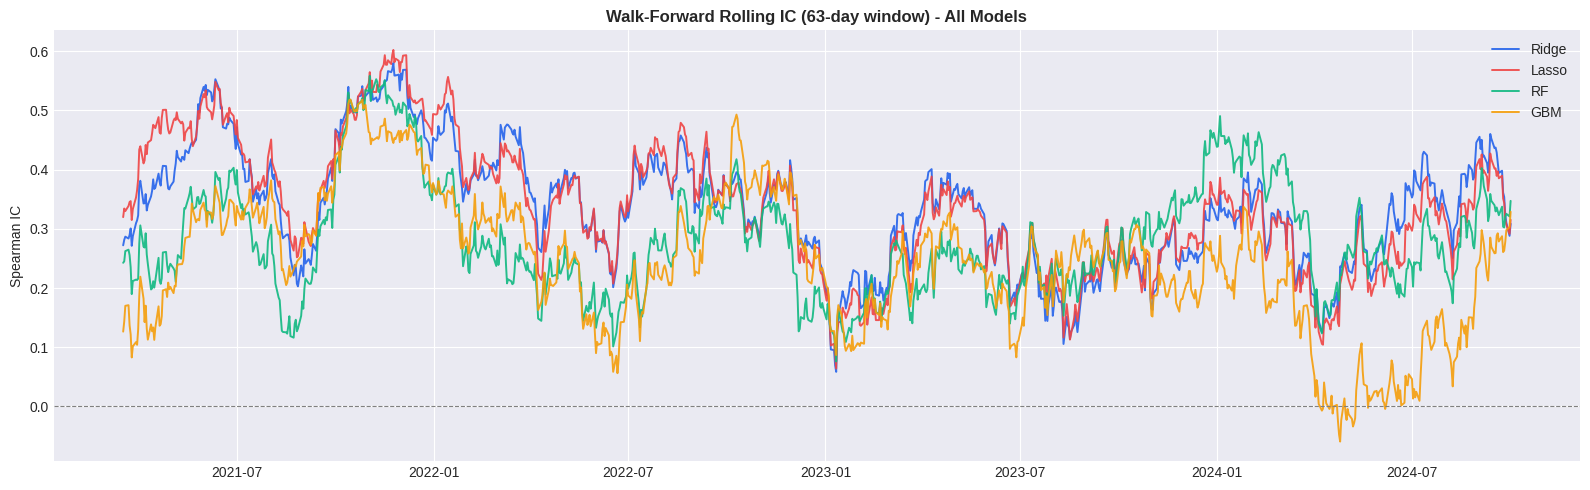

In [4]:
INIT_TRAIN = 252   # 1 year initial training
STEP       = 21    # monthly rebalancing

wf_results = {name: {"dates": [], "pred": [], "actual": []} for name in MODELS}

for t in range(INIT_TRAIN, N - STEP, STEP):
    X_train = scaler.fit_transform(X_df.values[:t])
    X_test  = scaler.transform(X_df.values[t:t+STEP])
    y_train = y_s.values[:t]
    y_test  = y_s.values[t:t+STEP]
    test_dates = dates[t:t+STEP]

    for mname, model in MODELS.items():
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)
        preds = m.predict(X_test)
        wf_results[mname]["dates"].extend(test_dates.tolist())
        wf_results[mname]["pred"].extend(preds.tolist())
        wf_results[mname]["actual"].extend(y_test.tolist())

# Compute rolling IC
fig, ax = plt.subplots(figsize=(16, 5))
for mname, color in zip(MODELS, COLORS):
    wf = pd.DataFrame({
        "pred":   wf_results[mname]["pred"],
        "actual": wf_results[mname]["actual"],
    }, index=pd.DatetimeIndex(wf_results[mname]["dates"]))
    roll_ic = wf.rolling(63).apply(
        lambda d: spearmanr(d, wf["actual"].reindex(d.index))[0]
        if len(d) == len(wf["actual"].reindex(d.index).dropna()) else np.nan,
        raw=False
    )["pred"]
    ax.plot(roll_ic.index, roll_ic, linewidth=1.4, color=color, label=mname, alpha=0.9)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Walk-Forward Rolling IC (63-day window) - All Models",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Spearman IC")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


## 5. Combinatorial Purged Cross-Validation

CPCV paths: 15


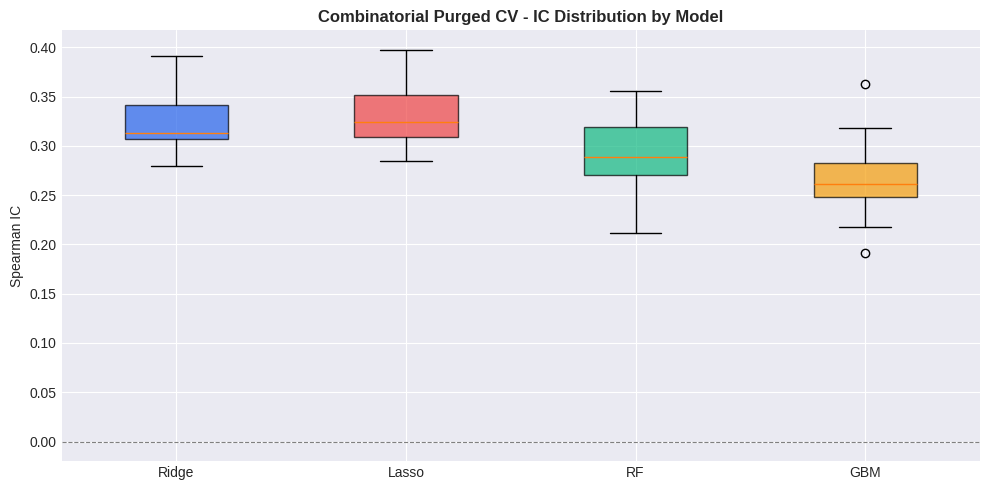

In [5]:
from itertools import combinations

def cpcv_splits(n, n_splits=6, n_test_splits=2, embargo_pct=0.01):
    """
    Combinatorial Purged CV (Lopez de Prado).
    Generate C(n_splits, n_test_splits) test path combinations.
    """
    embargo  = max(1, int(n * embargo_pct))
    fold_idx = np.array_split(np.arange(n), n_splits)
    paths    = []
    for test_folds in combinations(range(n_splits), n_test_splits):
        test_idx  = np.concatenate([fold_idx[k] for k in test_folds])
        purge_set = set()
        for k in test_folds:
            lo = max(0, fold_idx[k][0] - embargo)
            hi = min(n, fold_idx[k][-1] + embargo + 1)
            purge_set.update(range(lo, hi))
        train_idx = np.array([i for i in range(n)
                               if i not in set(test_idx) and i not in purge_set])
        paths.append((train_idx, test_idx))
    return paths

cpcv = cpcv_splits(N, n_splits=6, n_test_splits=2)
print(f"CPCV paths: {len(cpcv)}")

cpcv_ic = {name: [] for name in MODELS}
for train_idx, test_idx in cpcv:
    if len(train_idx) < 50 or len(test_idx) < 5:
        continue
    X_tr = scaler.fit_transform(X_df.values[train_idx])
    X_te = scaler.transform(X_df.values[test_idx])
    y_tr = y_s.values[train_idx]
    y_te = y_s.values[test_idx]
    for mname, model in MODELS.items():
        m = type(model)(**model.get_params())
        m.fit(X_tr, y_tr)
        ic, _ = spearmanr(m.predict(X_te), y_te)
        cpcv_ic[mname].append(ic)

fig, ax = plt.subplots(figsize=(10, 5))
data = [cpcv_ic[n] for n in MODELS]
bp = ax.boxplot(data, labels=list(MODELS.keys()), patch_artist=True)
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Combinatorial Purged CV - IC Distribution by Model",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Spearman IC")
plt.tight_layout()
plt.show()


## 6. Out-of-Sample Performance

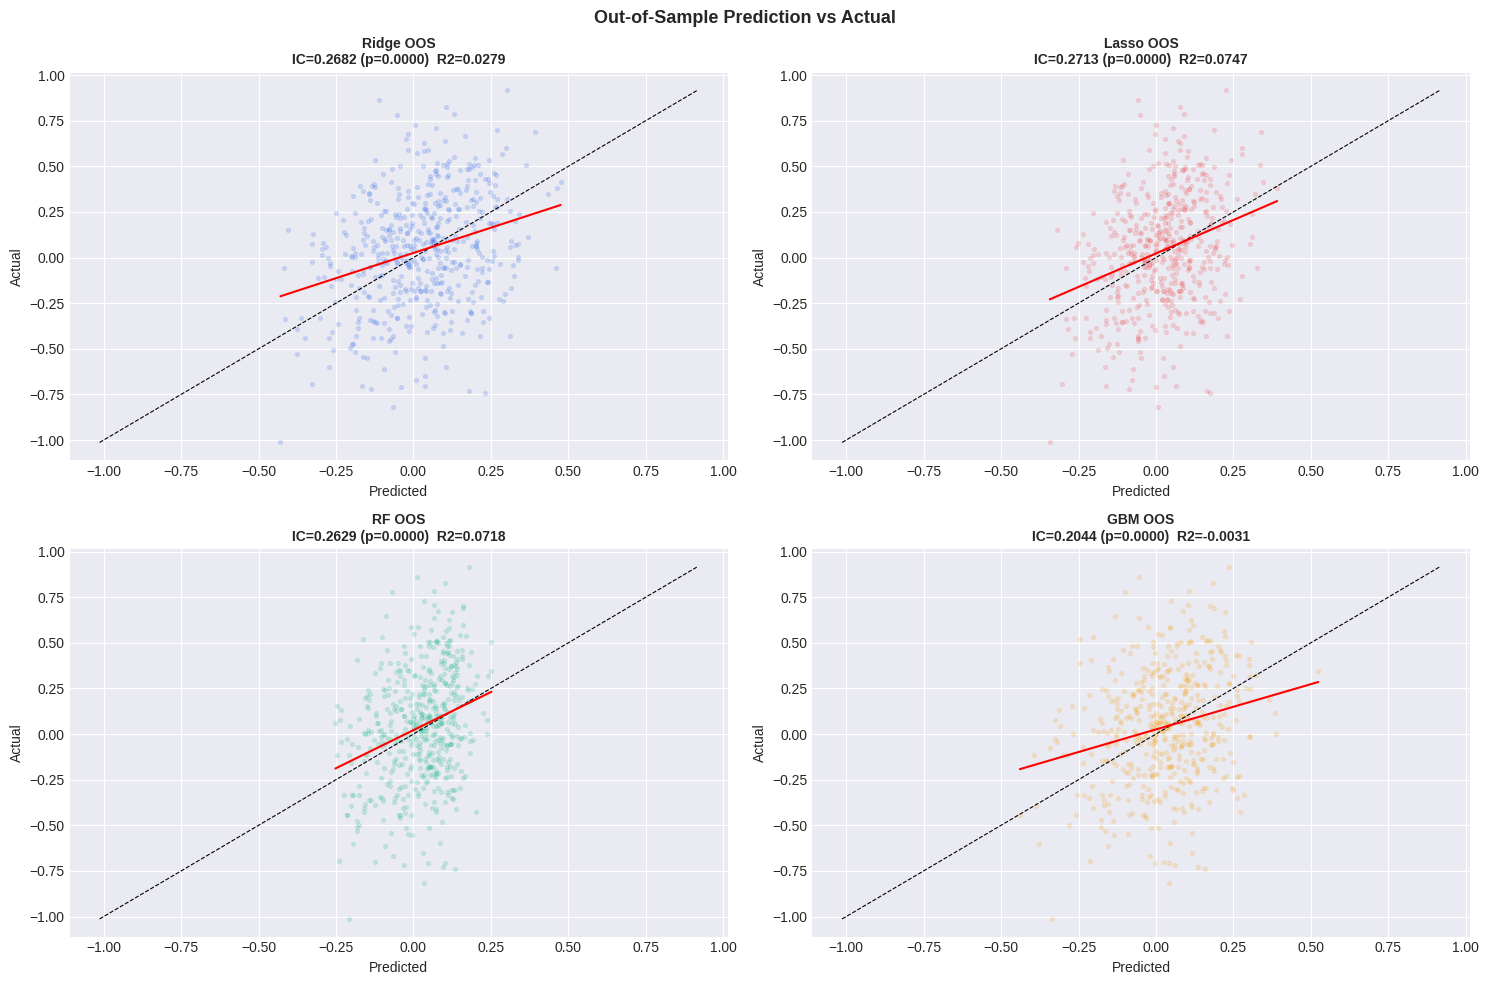

In [6]:
# True OOS: train on first 60%, test on last 40% (never seen by model)
split_idx  = int(N * 0.6)
X_is       = scaler.fit_transform(X_df.values[:split_idx])
X_oos      = scaler.transform(X_df.values[split_idx:])
y_is       = y_s.values[:split_idx]
y_oos      = y_s.values[split_idx:]
oos_dates  = dates[split_idx:]

oos_preds  = {}
for mname, model in MODELS.items():
    m = type(model)(**model.get_params())
    m.fit(X_is, y_is)
    oos_preds[mname] = m.predict(X_oos)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (mname, color) in zip(axes.ravel(), zip(MODELS, COLORS)):
    pred = oos_preds[mname]
    ic, pval = spearmanr(pred, y_oos)
    r2 = r2_score(y_oos, pred)

    ax.scatter(pred, y_oos, alpha=0.15, s=8, color=color)
    lims = [min(pred.min(), y_oos.min()), max(pred.max(), y_oos.max())]
    ax.plot(lims, lims, "k--", linewidth=0.8)

    m_fit, b_fit = np.polyfit(pred, y_oos, 1)
    x_line = np.linspace(pred.min(), pred.max(), 100)
    ax.plot(x_line, m_fit * x_line + b_fit, color="red", linewidth=1.5)

    ax.set_title(f"{mname} OOS\nIC={ic:.4f} (p={pval:.4f})  R2={r2:.4f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Out-of-Sample Prediction vs Actual", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Statistical Significance Testing

In [7]:
# Diebold-Mariano test for model comparison
def diebold_mariano(e1, e2, h=1):
    """
    DM test: H0 = e1 and e2 have equal forecast accuracy.
    e1, e2 are forecast error arrays. Returns (DM statistic, p-value).
    """
    d  = e1**2 - e2**2
    n  = len(d)
    d_bar = d.mean()
    gamma_0 = np.var(d, ddof=1)
    # Newey-West with h-1 lags
    gamma = sum(
        2 * (1 - j / h) * np.cov(d[j:], d[:-j])[0, 1]
        for j in range(1, h)
    ) if h > 1 else 0
    sigma2_d = (gamma_0 + gamma) / n
    dm_stat  = d_bar / np.sqrt(sigma2_d) if sigma2_d > 0 else 0
    pval     = 2 * stats.norm.sf(abs(dm_stat))
    return dm_stat, pval

# Benchmark: Ridge
bench_err = y_oos - oos_preds["Ridge"]
dm_rows = []
for mname in ["Lasso", "RF", "GBM"]:
    err = y_oos - oos_preds[mname]
    dm, pval = diebold_mariano(bench_err, err, h=5)
    better = "Yes" if dm > 0 and pval < 0.05 else "No"
    dm_rows.append({"vs Ridge": mname, "DM Stat": dm, "p-value": pval,
                     "Better than Ridge?": better})

dm_df = pd.DataFrame(dm_rows).set_index("vs Ridge")
print("Diebold-Mariano Test (H0: equal forecast accuracy vs Ridge baseline):")
display(dm_df.style.format({"DM Stat": "{:.3f}", "p-value": "{:.4f}"})
    .background_gradient(subset=["DM Stat"], cmap="RdYlGn")
)

# t-test on OOS IC
print("\nOOS IC t-tests (H0: IC = 0):")
for mname in MODELS:
    ic_series = pd.Series(oos_preds[mname]).rolling(21).corr(pd.Series(y_oos))
    tstat, pval = ttest_1samp(ic_series.dropna(), 0)
    print(f"  {mname:6s}  Mean IC={ic_series.mean():.4f}  t={tstat:.2f}  p={pval:.4f}")


Diebold-Mariano Test (H0: equal forecast accuracy vs Ridge baseline):


,DM Stat,p-value,Better than Ridge?
vs Ridge,,,
Lasso,3.435,0.0006,Yes
RF,1.691,0.0909,No
GBM,-1.098,0.2723,No



OOS IC t-tests (H0: IC = 0):
  Ridge   Mean IC=0.2904  t=40.22  p=0.0000
  Lasso   Mean IC=0.2912  t=39.84  p=0.0000
  RF      Mean IC=0.2710  t=40.73  p=0.0000
  GBM     Mean IC=0.2204  t=32.56  p=0.0000


## 8. Overfitting Detection

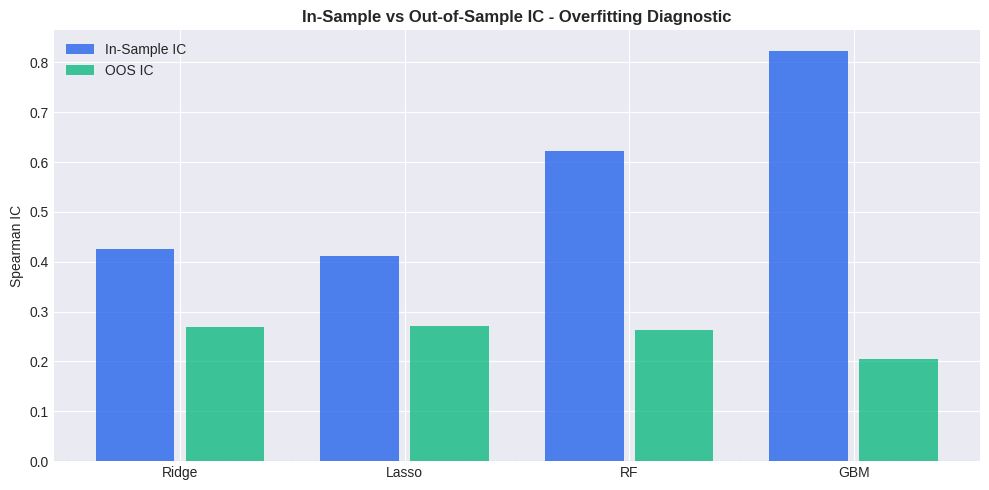

,In-Sample IC,OOS IC,IC Degradation,Overfit Ratio
Ridge,0.4262,0.2682,0.1580,0.6293
Lasso,0.4111,0.2713,0.1398,0.6599
RF,0.6220,0.2629,0.3591,0.4226
GBM,0.8230,0.2044,0.6186,0.2484


In [8]:
# Compare IS vs OOS IC across models
is_ic  = {}
oos_ic = {}
for mname, model in MODELS.items():
    m = type(model)(**model.get_params())
    m.fit(X_is, y_is)
    is_ic[mname]  = spearmanr(m.predict(X_is),  y_is)[0]
    oos_ic[mname] = spearmanr(oos_preds[mname], y_oos)[0]

overfit_df = pd.DataFrame({"In-Sample IC": is_ic, "OOS IC": oos_ic})
overfit_df["IC Degradation"] = overfit_df["In-Sample IC"] - overfit_df["OOS IC"]
overfit_df["Overfit Ratio"]  = overfit_df["OOS IC"] / overfit_df["In-Sample IC"]

fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(MODELS))
ax.bar(x - 0.2, overfit_df["In-Sample IC"], width=0.35,
       label="In-Sample IC", color=COLORS[0], alpha=0.8)
ax.bar(x + 0.2, overfit_df["OOS IC"],      width=0.35,
       label="OOS IC", color=COLORS[2], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(MODELS.keys()))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("In-Sample vs Out-of-Sample IC - Overfitting Diagnostic",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Spearman IC")
ax.legend()
plt.tight_layout()
plt.show()

display(overfit_df.style
    .background_gradient(subset=["IC Degradation"], cmap="RdYlGn_r")
    .background_gradient(subset=["Overfit Ratio"],  cmap="RdYlGn")
    .format("{:.4f}")
)


## 9. Feature Importance and Stability

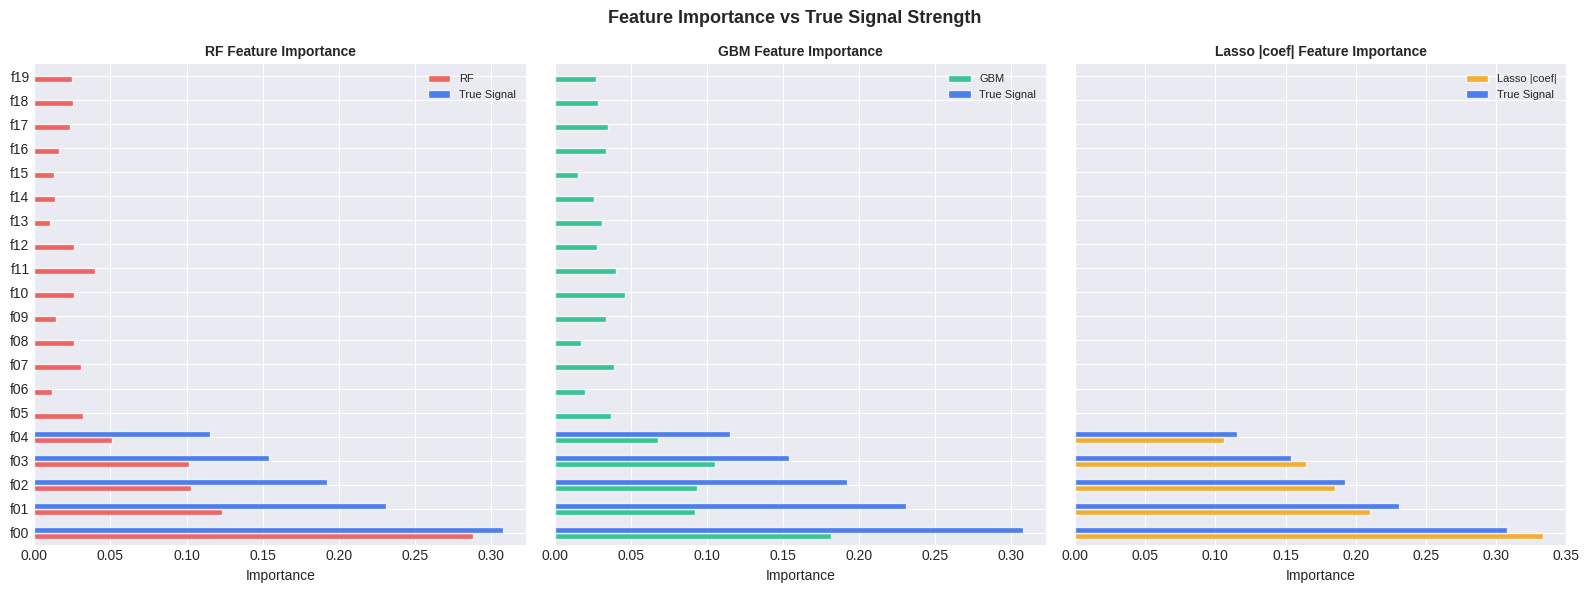

In [9]:
# Feature importance from RF and GBM, vs true coefficients
rf_final  = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=SEED)
gbm_final = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED)
lasso_final = LassoCV(cv=5, max_iter=2000, random_state=SEED)

rf_final.fit(X_is, y_is)
gbm_final.fit(X_is, y_is)
lasso_final.fit(X_is, y_is)

feat_names = X_df.columns.tolist()
imp_df = pd.DataFrame({
    "True Signal":  np.abs(true_coef) / np.abs(true_coef).sum(),
    "RF":           rf_final.feature_importances_,
    "GBM":          gbm_final.feature_importances_,
    "Lasso |coef|": np.abs(lasso_final.coef_) / (np.abs(lasso_final.coef_).sum() + 1e-8),
}, index=feat_names).sort_values("True Signal", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
for ax, (col, color) in zip(axes, zip(["RF","GBM","Lasso |coef|"], COLORS[1:])):
    imp_df[[col, "True Signal"]].plot.barh(ax=ax, color=[color, COLORS[0]],
                                            edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} Feature Importance", fontsize=10, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.legend(fontsize=8)

plt.suptitle("Feature Importance vs True Signal Strength",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Validation Report Summary

In [10]:
print("=" * 65)
print("  ALPHAMIND MODEL VALIDATION REPORT")
print("=" * 65)
print()
print("Purged K-Fold CV (5 folds, 1% embargo):")
for mname, row in cv_summary.iterrows():
    print(f"  {mname:6s}  Mean IC={row['Mean IC']:.4f}  ICIR={row['ICIR']:.3f}")
print()
print("Out-of-Sample Performance (last 40%):")
for mname in MODELS:
    ic  = spearmanr(oos_preds[mname], y_oos)[0]
    r2  = r2_score(y_oos, oos_preds[mname])
    deg = overfit_df.loc[mname, "IC Degradation"]
    print(f"  {mname:6s}  OOS IC={ic:.4f}  R2={r2:.4f}  IC Degradation={deg:.4f}")
print()
best = max(oos_ic, key=oos_ic.get)
print(f"Recommended model: {best} (highest OOS IC = {oos_ic[best]:.4f})")
print("=" * 65)


  ALPHAMIND MODEL VALIDATION REPORT

Purged K-Fold CV (5 folds, 1% embargo):
  Ridge   Mean IC=0.3341  ICIR=5.060
  Lasso   Mean IC=0.3393  ICIR=4.747
  RF      Mean IC=0.2982  ICIR=4.845
  GBM     Mean IC=0.2683  ICIR=5.959

Out-of-Sample Performance (last 40%):
  Ridge   OOS IC=0.2682  R2=0.0279  IC Degradation=0.1580
  Lasso   OOS IC=0.2713  R2=0.0747  IC Degradation=0.1398
  RF      OOS IC=0.2629  R2=0.0718  IC Degradation=0.3591
  GBM     OOS IC=0.2044  R2=-0.0031  IC Degradation=0.6186

Recommended model: Lasso (highest OOS IC = 0.2713)
